COSTRUZIONE DI UNA RNN PER NLP CON TENSORFLOW E KERAS

La costruzione di una RNN per NLP con TensorFlow e Keras significa creare una rete che riceve una sequenza di token, la trasforma in vettori e poi la elabora mantentendo memoria di ciò che ha visto prima.
La pipeline è
testo -> TextVectorization/tokenizer -> token ID -> embedding -> RNN -> Dense -> Predizione

La parte fondamentale è che la RNN legge la sequenza nell'ordine.
Prendiamo la frase:
"il film non è bello"
dopo la tokenizzazoine potresti avere:
[12,54,31,7,96]
Poi l'Embedding trasforma ogni ID in un vettore
Quindi la RNN non riceve direttamente parole, nè ricevo ID, ma una sequenza di vettori
Il cuore della RNN è l'hidden stato
ad ogni passo:
input corrente + hidden state precedente = nuovo hidden state

Quindi schematicamente con Keras, una RNN semplice può essere costruita così:
import keras
model = 
    keras.Sequential([
        keras.layers.Embedding(input_dim=10000,output_dim=64),
        keras.layers.SimpleRNN(32),
        keras.layers.Dense(1,activation="sigmoid")
])

Abbiamo 3 blocchi
    1) layer embedding
    2) layer SimpleRNN: significa che la RNN ha uno stato nascosto di dimensione 32, quindi alla fine la RNN sintetizza la sequenza in un vettore di 32 numeri, che rappresenta ciò che la rete ha ricavato dal testo.
    3) infine: layer.Dense, serve per la classificazione binaria 0=negativo 1=positivo. La sigmoid produce un valore tra 0 e 1
prima dei 3 blocchi però devi trasformare il testo in token id.
Con Keras puoi utilizzare TextVectorization, poi fai il fit del vocabolario con vectorizer.adapt.
Adapt non addestra una RNN serve solo a far imparare al vectorizer quali parole esistono e quele ID assegnare.

Usiamo tensorflow e Keras per dare memoria al nostro modello

Lo strumento principale è il Layer Simple RNN in Keras
In Keras la teorica incontra la semplicità
Per imprementare una rete ricorrente, non dobbiamo scrivere righe e righe di codice.
Il layer SimpleRNN farà il lavoro pesante per noi.
Pensa a questo layer come ad un impiegato molto diligente, che legge una parola alla volta e prende appunti su un taccuino. 
Questi appunti sono lo stato nascosto e Keras lo gestisce automaticamente.
Noi dobbiamo solo decidere quanto deve essere grande questo taccuino e come deve essere strutturato l'input
Oltre alla definizione del numero di neuroni, è fondamentale comprendere come Keras gestisce lo stato nascosto tra i diversi step temporali della sequenza di input.

Configurare una RNN significa bilanciare potenza a precisione. 
Il parametro 'units' è fondamentale, definisce la dimensionalità dello spazio dello stato nascosto, ovvero la memoria interna del layer. Troppo piccola e la rete dimentica tutto, troppo grande e rischiamo l'overfitting.
Un altro parametro fondamentale è 'return_sequences' se la nostra RNN è solo una parte di un sistema di più grande, potremmo volere che ci racconti tutto quello che ha visto, oppure vogliamo solo il riassunto finale. Infine usiamo la tanh per gestire i valori dello stato nascosto in un range stabile.

Ma come fluiscono questi dati tra un layer e l'altro?
Flusso dei Dati e Output
Normalmente SimpleRNN restituisce solo l'ultimo vettore della sequenzale, ideale per task di classificazione testuale. Leggi tutta la frase e dimmi se è positiva o negativa.
Per creare architetture più profonde, dobbiamo concatenare più RNN, in questo caso il primo layer, deve passare l'intera sequenza al secondo e così via (non si passa solo la staffetta finale, ma ogni informazione utile), fino all'ultimo, impostare 'retun_sequences=True' per alimentare il layer successivo.
Keras utilizza 'glorot_uniform' per i pesi di input e 'orthogonal' per i pesi ricorrenti, garantendo stabilità iniziale.

Il layer calcola lo stato corrente combinando l'input attuale con lo stato precedente tramite matrici di peso distinte. Questa formula è solo il modo in cui il modello aggiorna il suo taccuino ricordando anche le informazioni che arrivano dai layer precedenti.
Questa operazione viene ripetuta per ogni elemento della sequenza temporale fornita in input.

Ma cosa succede se questo calcolo diventa instabile.
Le sfide dell'adestramento
Ottimizzare l'addestramento delle reti ricorrenti
Le RNN sono notoriamente difficili da addestrare a causa della propagazione dell'errore attraverso  molti step temporali. Più la sequenza è lunga più l'addestramento è difficile.
Problemi come l'esplosione o la scomparsa del gradiente rendono la scelta degli iperparametri, in particolare il learning rate, una fase critica, diventando una questione di sopravivenza del modello.

Quali sono gli iperparametri che ci permettono di mantenere in vita il modello?

Iperparametri di Controllo
Strategie per una convergenza robusta.
- Learning Rate: una valore troppo alto causa oscillazioni violente, un valore troppo basso blocca l'apprendimento. E' il nostro accelleratore, ma deve essere equilibrato.
- Ottimizzatori: 'RMSprop' e 'Adam' sono spesso preferiti a 'SGD' per la gestione adattiva dei momenti
- Gradient Clipping: tecnica per limitare forzatamente la norma del gradiente ed evitare divergenze numeriche. Se il gradiente cerca di esplodere oltre un valore noi lo tagliamo forzatamente.
- Batch Size: influisce sulla stima del gradiente e sulla velocità di convergenza per sequenze lunghe.

Ora che abbiamo costruito e messo in sicurezza il modello, come facciamo a capire se sta funzionando?

Analisi dei Grafici di Apprendimento
Diagnosticare lo stasto del modello attraverso la visualizzazione
Monitorare l'andamento della loss e dell'accuratezza (sia sul trainng sia sul validation set) è l'unico modo per capire se la RNN sta davvero imparando.
I grafici permettono di distinguere tra problemi di convergenza, overfitting, o semplice rumore nei dati.

Se la loss del training scende ma quella della validation sale, siamo difronte ad overfitting, il modello sta imparando a memoria il dataset
Se vedete oscillazioni violente, probabilmente il learning rate è troppo alto. Il modello sta saltando da una parte all'altra del minimo, senza mai caderci dentro.
Un Plateau (curva piatta) ci dice che il modello ha raggiunto la capacità massima o è bloccato. Siamo a corto di idee

Quali Strumenti abbiamo?
* Matplotlib: la visualizzazione con matplotlib è il nostro primo strumento di analisi. L'oggetto 'history' restituito da model.fit() contiene i dizionari necessari per generare grafici personalizzati
* Early Stopping: callback che interrompe il training quando la validation loss smette di migliorare, basandosi sul trend visualizzati. Con questo possiamo automatizzare le azioni.
* Learning Rate Decay: osservando un plateau, possiamo decidere di ridurre il learning rate per 'rifinire' la convergenza verso il minimo.

Se la curva di training e quella di validation rimangono alte, il modello non ha abbastanza capacità (underfitting)
Se la training loss scende ma la validation sale, il modello sta memorizzando il rumore (overfitting)
Un modello che generalizza bene è un modello che ha catturato la struttura profonda del linguaggio

>>> 1. Sto creando il set di dati simulato...
>>> 2. Sto assemblando la rete neurale (SimpleRNN)...


Model: "Esempio_RNN_Studenti"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 20, 32)         │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,473 (37.00 KB)

 Trainable params: 9,473 (37.00 KB)

 Non-trainable params: 0 (0.00 B)

>>> 3. Inizia l'addestramento! Il modello sta cercando i pattern nei dati...
Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.4875 - loss: 0.6997 - val_accuracy: 0.4950 - val_loss: 0.7021
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.6562 - loss: 0.6525 - val_accuracy: 0.4800 - val_loss: 0.7411
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.7163 - loss: 0.5684 - val_accuracy: 0.4600 - val_loss: 0.8806
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8025 - loss: 0.4619 - val_accuracy: 0.4250 - val_loss: 0.9801
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8325 - loss: 0.3793 - val_accuracy: 0.4050 - val_loss: 1.0962
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8587 - loss: 0.3289 - val_accuracy: 0.4350 - val_loss: 1.2284
>>> 4. Fine addestramento. Sto generando i grafici finali...


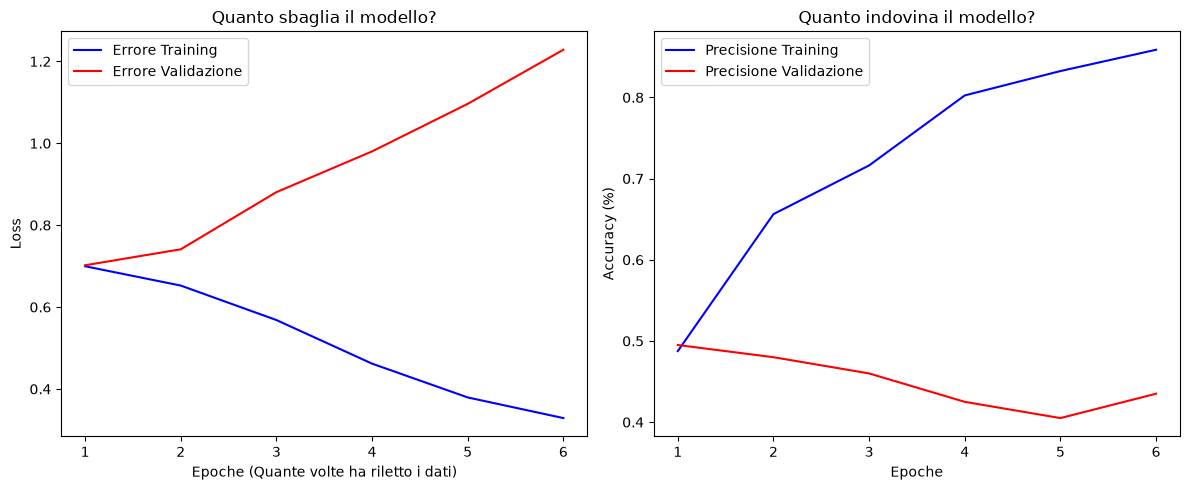

In [ ]:
"""
================================================================================
COSTRUZIONE DI UNA RETE RICORRENTE (RNN) PER NLP
================================================================================
Funzionamento di una una RNN. Il flusso logico è il seguente:
1. PREPARAZIONE DATI: Generiamo "frasi" (sequenze di numeri) e "sentimenti" (0 o 1).
2. ARCHITETTURA: Creiamo una catena di montaggio (il Modello) dove:
   - Input: Riceve i dati grezzi.
   - Embedding: Traduce i numeri in concetti (vettori).
   - SimpleRNN: Elabora la sequenza cercando di "ricordare" le parole precedenti.
   - Dense: Prende la decisione finale (0 o 1).
3. TRAINING: Il modello prova, sbaglia, vede l'errore e si corregge tramite l'Ottimizzatore.
4. ANALISI: Guardiamo i grafici per capire se il modello ha imparato davvero.
================================================================================
"""

import os

# --- 1. CONFIGURAZIONE DEL BACKEND ---
# Keras 3 può usare diversi "motori" (PyTorch, TensorFlow, JAX).
# Qui diciamo a Keras di usare PyTorch per tutti i calcoli matematici pesanti.
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import layers, ops
import numpy as np
import matplotlib.pyplot as plt

def generate_dummy_data(num_samples=1000, max_len=20):
    """
    Simula la creazione di un dataset per addestrare l'intelligenza artificiale.
    
    Interazione: Questi dati saranno "mangiati" dal modello durante la fase .fit().
    
    Args:
        num_samples: Quante frasi simulate vogliamo creare.
        max_len: Quante parole (numeri) ci sono in ogni frase.
    """
    # Generiamo numeri casuali tra 1 e 100 per simulare indici di parole in un vocabolario
    # Output: Una matrice [1000 righe, 20 colonne]
    x = np.random.randint(1, 100, size=(num_samples, max_len))
    
    # Creiamo una regola logica che il modello dovrà scoprire:
    # Se la somma degli indici è pari, l'etichetta è 1 (positivo), altrimenti 0 (negativo).
    # .astype(int) trasforma i valori Booleani (True/False) in 1 e 0.
    y = (np.sum(x, axis=1) % 2 == 0).astype(int)
    
    # Separiamo i dati: l'80% per studiare (Train), il 20% per interrogarlo dopo (Validation).
    split = int(num_samples * 0.8)
    return (x[:split], y[:split]), (x[split:], y[split:])

def build_rnn_model(max_len, vocab_size, rnn_units=64):
    """
    Costruisce la struttura del cervello artificiale (Il Modello).
    
    Interazione tra Layer:
    - Input riceve i dati -> Embedding trasforma i dati -> RNN elabora la sequenza -> Dense decide.
    """
    
    # --- STEP A: DEFINIZIONE DELL'INGRESSO ---
    # Definiamo la "forma" del dato in entrata: liste lunghe 'max_len' (20 nel nostro caso).
    inputs = layers.Input(shape=(max_len,))
    
    # --- STEP B: IL TRADUTTORE (EMBEDDING) ---
    # Poiché l'IA non capisce gli interi, questo layer associa ogni numero a un vettore di 32 cifre decimali.
    # Queste cifre cambieranno durante il training per raggruppare "parole" simili.
    embedding = layers.Embedding(input_dim=vocab_size, output_dim=32)(inputs)
    
    # --- STEP C: IL CUORE DELLA RNN (SIMPLERNN) ---
    # Qui avviene la magia della ricorsione. Il layer legge la sequenza una "parola" alla volta.
    # - 'units=64': Il numero di neuroni (memoria interna).
    # - 'return_sequences=False': Ci restituisce solo il risultato finale della lettura (Many-to-One).
    # - 'kernel_initializer/recurrent_initializer': Impostano come devono nascere i pesi (i "neuroni") 
    #   per evitare che il modello parta con valori troppo alti o troppo bassi.
    rnn_output = layers.SimpleRNN(units=rnn_units, 
                                  activation="tanh", 
                                  return_sequences=False,
                                  kernel_initializer="glorot_uniform",
                                  recurrent_initializer="orthogonal")(embedding)
    
    # --- STEP D: IL DECISORE FINALE (DENSE) ---
    # Un singolo neurone finale. L'attivazione 'sigmoid' schiaccia il risultato tra 0 e 1.
    # Se il valore è vicino a 1, il modello dirà "Positivo", se vicino a 0 "Negativo".
    outputs = layers.Dense(1, activation="sigmoid")(rnn_output)
    
    # Creiamo l'oggetto Modello che unisce l'inizio (inputs) alla fine (outputs)
    model = keras.Model(inputs=inputs, outputs=outputs, name="Esempio_RNN_Studenti")
    
    # --- STEP E: REGOLE DI ADDESTRAMENTO (COMPILAZIONE) ---
    # - 'learning_rate=0.001': La velocità con cui il modello corregge i propri errori.
    # - 'clipnorm=1.0': -> Se il modello riceve un segnale troppo forte che potrebbe 
    #   confonderlo (Exploding Gradient), lo "taglia" a 1.0 per rimanere stabile.
    optimizer = keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)
    
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy", # Funzione di errore per problemi a due scelte (0/1)
        metrics=["accuracy"]        # Vogliamo monitorare la percentuale di risposte esatte
    )
    
    return model

def plot_history(history):
    """
    Trasforma il "diario dell'addestramento" in grafici leggibili.
    
    Interazione: Prende l'input dall'oggetto 'history' creato dal comando .fit().
    """
    # Estraiamo i dati di accuratezza e perdita registrati epoche dopo epoche
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Creiamo una finestra con due grafici affiancati
    plt.figure(figsize=(12, 5))

    # GRAFICO 1: ERRORE (LOSS) - Più scende, meglio è!
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss, 'b-', label='Errore Training')
    plt.plot(epochs_range, val_loss, 'r-', label='Errore Validazione')
    plt.title('Quanto sbaglia il modello?')
    plt.xlabel('Epoche (Quante volte ha riletto i dati)')
    plt.ylabel('Loss')
    plt.legend()

    # GRAFICO 2: ACCURACY - Più sale, meglio è!
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, acc, 'b-', label='Accuracy Training')
    plt.plot(epochs_range, val_acc, 'r-', label='Accuracy Validazione')
    plt.title('Quanto indovina il modello?')
    plt.xlabel('Epoche')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()

# ================================================================================
# FASE DI ESECUZIONE (IL MAIN)
# ================================================================================

if __name__ == "__main__":
    # 1. Settiamo le costanti
    MAX_LEN = 20        # Lunghezza delle frasi
    VOCAB_SIZE = 100    # Numero di parole diverse disponibili
    
    # 2. Generiamo i dati (Interazione: Dati -> Modello)
    print(">>> 1. Sto creando il set di dati simulato...")
    (x_train, y_train), (x_val, y_val) = generate_dummy_data(max_len=MAX_LEN)
    
    # 3. Costruiamo il modello (Interazione: Architettura -> Configurazione)
    print(">>> 2. Sto assemblando la rete neurale (SimpleRNN)...")
    model = build_rnn_model(max_len=MAX_LEN, vocab_size=VOCAB_SIZE)
    model.summary() # Questa tabella mostra quanti "neuroni" (parametri) verranno addestrati
    
    # 4. Iniziamo lo studio (Training)
    print(">>> 3. Inizia l'addestramento! Il modello sta cercando i pattern nei dati...")
    
    # Il Callback EarlyStopping interrompe lo studio se il modello inizia a imparare a memoria (Overfitting)
    # invece di capire i concetti generali. 'patience=3' significa: aspetta 3 volte se non migliori.
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    # .fit() è il cuore: Qui il modello legge x_train, prova a indovinare y_train e si corregge.
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val), # Gli diamo dati che non ha mai visto per metterlo alla prova
        epochs=30,          # Numero massimo di volte che può leggere tutto il dataset
        batch_size=32,      # Quanti esempi legge prima di correggersi (un "pacchetto")
        callbacks=[early_stop],
        verbose=1           # Mostra il progresso riga per riga nella console
    )
    
    # 5. Visualizziamo i risultati (Interazione: Storia -> Grafici)
    print(">>> 4. Fine addestramento. Sto generando i grafici finali...")
    plot_history(history)

Cosa netto di overfitting. il modello sta imparando sempre meglio i dati di training, ma contemporaneamente sta peggiorando sui dati di validazione.
Nel grafico di sx la loss del training scende circa da 0.7 a 0.33, sembra buono se non confrontato con il grafico di validation.
Quindi sui dati che il modello conosce commette sempre meno errori.
Ma la validation loss fa esattamente il contrario, parte da 0.7 ed arriva a 1.23, quindi sui dati che non ha mai visto, il modello commette errori sempre maggiori.
Segnale di overfitting.
Il grafico di dx conferma la stessa cosa, anche l accuracy miglio sui dati di training mentre peggiora sempre sui dati di validation.
E' uno studente che impara a memoria le risposte del libro, non ha generalizzato.
L'overfitting sembra iniziare quasi immediatamente. La validation loss è minima alla prima epoca e poi comincia già a salire.

Il modello è in forte overfitting: durante le epoche migliora continuamente sul training set, mentre le prestazioni sul validation set peggiorano. Sta memorizzando i dati di training invece di imparare caratteristiche che generalizzano su dati nuovi.

Il modello non riesce a migliorare a causa della natura randomica dei sui dati.